In [1]:
import json
import numpy as np

NS_PATH = "data/ns/"

ns_elites_path = NS_PATH + "elites.json"

with open(ns_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))
print("Elite keys:", elites[0].keys())

Number of elites: 501
Elite keys: dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells', 'trackSize', 'fitness', 'embedding', 'archiveIndex'])


Speed metric has 0 zeros out of 4851890 values.
Steering metric has 3155 zeros out of 4851890 values.
Distance from side metric has 0 zeros out of 4851890 values.
[ 6.48648e+01  1.33923e-02  1.36024e+01  6.44346e+01  1.25898e-02
  1.45230e+01  6.12907e+01  1.66727e-02  1.52328e+01  5.88738e+01
  1.16239e-02  1.57138e+01  5.63204e+01  9.90176e-03  1.59846e+01
  5.33297e+01  2.91854e-02  1.58849e+01  5.05997e+01  6.01993e-02
  1.50476e+01  4.80661e+01  7.13042e-02  1.38793e+01  4.53817e+01
  5.94559e-02  1.27933e+01  4.22669e+01  1.02398e-01  1.19783e+01
  3.93941e+01  1.36476e-01  1.08838e+01  3.67537e+01  9.13402e-02
  9.36253e+00  3.41676e+01  4.60505e-02  7.55041e+00  3.17199e+01
  5.13559e-02  5.56259e+00  2.98514e+01  8.20393e-02  3.61915e+00
  2.78984e+01  1.40707e-01  2.07293e+00  2.66778e+01  1.34022e-01
  1.39994e+00  2.57959e+01  1.36723e-01  1.25452e+00  2.48884e+01
  1.44432e-01  1.26951e+00  2.43360e+01  1.48668e-01  1.29597e+00
  2.38404e+01  1.63736e-01  1.28703e+00  2.31

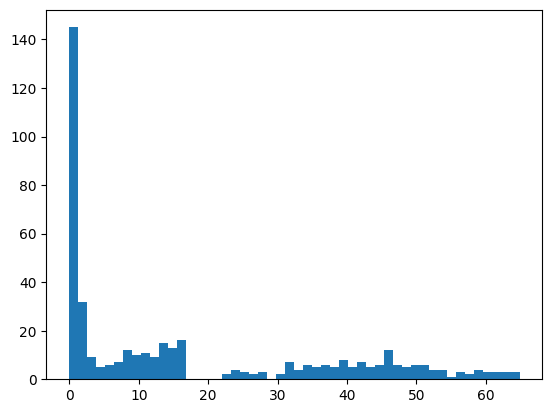

In [2]:
# load dataset at : qd\embeddings\datasets\dataset20k_metrics_mixedRng_tita.npz
import matplotlib.pyplot as plt

dataset = np.load("qd/embeddings/datasets/dataset20k_metrics_mixedRng_tita_canonicized.npz")
flat_metrics = dataset["data"]
indices = dataset["indices"]
ids = dataset["ids"]

flat_metrics = np.delete(flat_metrics, [0,3,4,5], axis=1)

# get separate metrics based on indices in order speed steering dist_from_side
speed_metrics = flat_metrics[:, 0]
steering_metrics = flat_metrics[:, 1]
dist_from_side_metrics = flat_metrics[:, 2]

# count the 0s in each metric
speed_zero_count = sum(1 for x in speed_metrics if x == 0)
steering_zero_count = sum(1 for x in steering_metrics if x == 0)
dist_from_side_zero_count = sum(1 for x in dist_from_side_metrics if x == 0)

print(f"Speed metric has {speed_zero_count} zeros out of {len(speed_metrics)} values.")
print(f"Steering metric has {steering_zero_count} zeros out of {len(steering_metrics)} values.")
print(f"Distance from side metric has {dist_from_side_zero_count} zeros out of {len(dist_from_side_metrics)} values.")

metrics = np.split(flat_metrics, indices)

# pick a 10 random metrics and print the 0 percentage for each of them
for i in range(1):
    metric = metrics[i]
    flattened_metric = metric.flatten()
    print(flattened_metric)
    #plot number distribution of values in the metric
    plt.hist(flattened_metric, bins=50)
    plt.show()

In [4]:
import sys
from qd.qd_runner import QDRunner
import qd.emitter as emitter_module
import qd.utils as utils_module
import qd.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'qd.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = NS_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
stats = state["stats"]

2026-06-21 18:02:16 [info     ] Checkpoint loaded              path=data/ns/checkpoints\checkpoint_1100.pkl resume_iter=1101


In [5]:
# Select elites of interest (used by the cells below).
selected_elite_ids = [
    936.8469441105242,
    984.1748238448697,
    1024.844219242639,
    638.7066598660713
]

# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in selected_elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

# print embeddings of selected elites
for i, elite in enumerate(selected_elites):
    print(f"Elite ID: {elite['id']}")
    print(f"Embedding: {elite['embedding']}")
    print()

Elite ID: 936.8469441105242
Embedding: [-1.1035337448120117, -0.16564561426639557, -0.6739351749420166, 0.9167541265487671, 0.9622296094894409, 0.6219345331192017, -0.3241259455680847, 0.29214242100715637, 1.2986445426940918, 0.9506403803825378, 0.14180436730384827, -1.3230040073394775, 0.1309172362089157, 0.3016371726989746, 1.0028717517852783, 0.9067807793617249, -1.127855896949768, 1.1255080699920654, -1.2340434789657593, 1.6283801794052124, 1.904420018196106, -0.06298506259918213, -0.01214863546192646, -0.5147123336791992, 0.9269247055053711, 1.326090931892395, 0.8378762602806091, -0.35505211353302, 0.2389952838420868, -1.5004802942276, 0.0188857801258564, 2.0332014560699463]

Elite ID: 984.1748238448697
Embedding: [1.223380446434021, 1.300154209136963, 0.4201640486717224, 1.52555513381958, 0.049003418534994125, 1.963598370552063, 0.8815149664878845, -0.9929339289665222, 0.3337630331516266, -1.6872833967208862, 1.862685203552246, -0.6523175835609436, 0.3301762640476227, 0.088497117

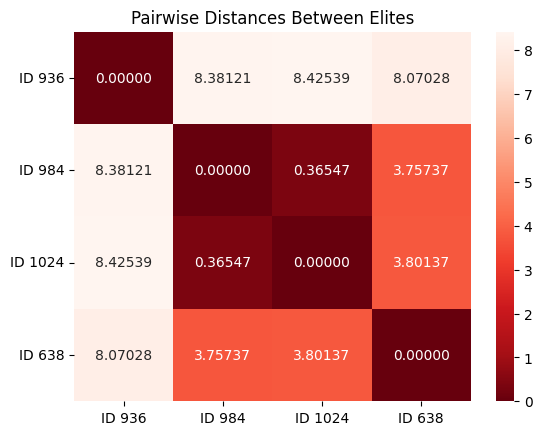

In [6]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {int(id)}" for id in selected_elite_ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".5f")
plt.title("Pairwise Distances Between Elites")
plt.yticks(rotation=0)
plt.show()

Elite ID: 936.8469441105242
Distances: [4.09812827 5.1649245  5.37539121 5.6556242  5.69862069 5.77714578
 5.77951315 5.86351547 5.91054353 5.91590568 5.93624163 6.01988984
 6.23542769 6.24896092 6.2742687 ]
Mean distance to neighbors: 5.73027
---


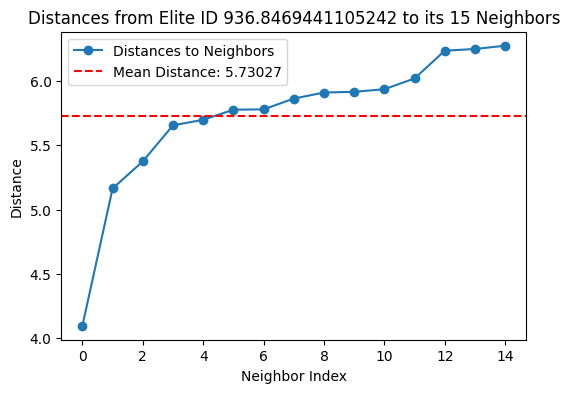

Elite ID: 984.1748238448697
Distances: [5.62248334 5.88026287 5.89435674 5.95869686 6.08964947 6.14717075
 6.25396627 6.32250487 6.32962049 6.33007709 6.35694421 6.36529517
 6.37430473 6.39631402 6.3992136 ]
Mean distance to neighbors: 6.18139
---


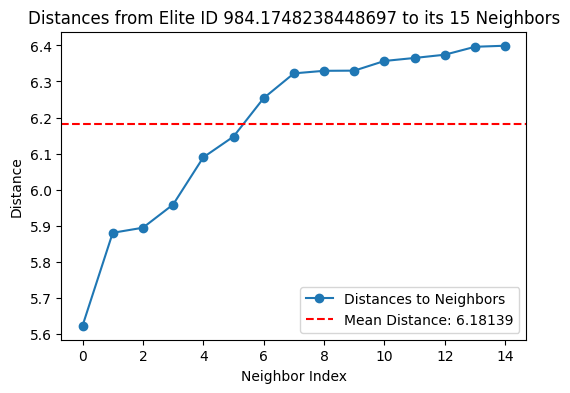

Elite ID: 1024.844219242639
Distances: [5.6778524  5.84858701 5.97593045 6.04971988 6.10031127 6.11819692
 6.26032117 6.28327681 6.30182121 6.31437144 6.32853942 6.33300176
 6.35239647 6.41452371 6.4278225 ]
Mean distance to neighbors: 6.18578
---


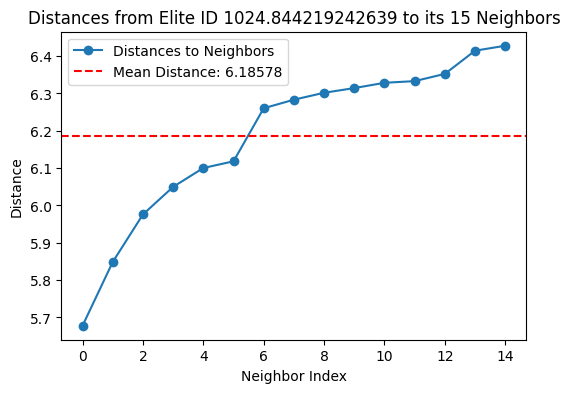

Elite ID: 638.7066598660713
Distances: [5.35232625 5.51107603 5.53081925 5.67795021 5.78278661 5.94939379
 5.99302853 6.10376545 6.16450201 6.20944323 6.2128819  6.23048156
 6.26993508 6.29260463 6.32072956]
Mean distance to neighbors: 5.97345
---


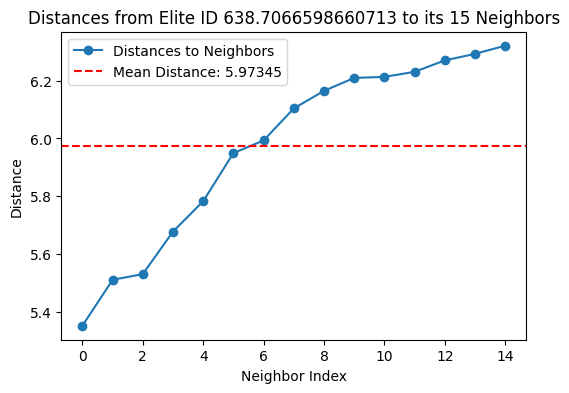

In [7]:
# compute kNeighbors for each elite
from sklearn.neighbors import NearestNeighbors


elites_minus_selected = [elite for elite in elites if elite["id"] not in selected_elite_ids]

elite_embeddings = [elite["embedding"] for elite in elites_minus_selected]

n_neighbors = 15
knn = NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(elite_embeddings)

for i, elite in enumerate(selected_elites):
    elite_id = elite["id"]
    elite_embedding = elite["embedding"]
    distances, indices = knn.kneighbors([elite_embedding])
    mean_distance = np.mean(distances)
    print(f"Elite ID: {elite_id}")
    print(f"Distances: {distances[0]}")
    print(f"Mean distance to neighbors: {mean_distance:.5f}")
    print("---")
    # plot distances and mean distance
    plt.figure(figsize=(6, 4))
    plt.plot(distances[0], marker='o', label='Distances to Neighbors')
    plt.axhline(mean_distance, color='red', linestyle='--', label=f'Mean Distance: {mean_distance:.5f}')
    plt.title(f"Distances from Elite ID {elite_id} to its {n_neighbors} Neighbors")
    plt.xlabel("Neighbor Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()

Elite ID: 936.8469441105242
Distances: [4.09812827 5.1649245  5.37539121 5.6556242  5.69862069 5.77714578
 5.77951315 5.86351547 5.91054353 5.91590568 5.93624163 6.01988984
 6.23542769 6.24896092 6.2742687 ]
Mean distance to neighbors: 5.73027
---


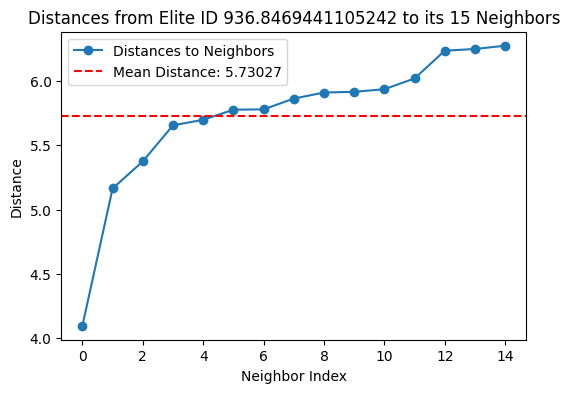

Elite ID: 984.1748238448697
Distances: [0.36547131 3.75736819 5.62248334 5.88026287 5.89435674 5.95869686
 6.08964947 6.14717075 6.25396627 6.32250487 6.32962049 6.33007709
 6.35694421 6.36529517 6.37430473]
Mean distance to neighbors: 5.60321
---


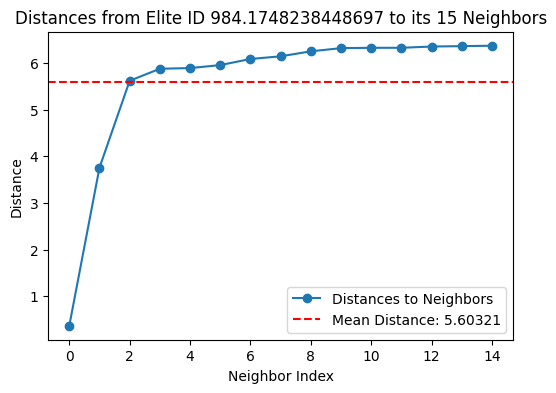

Elite ID: 1024.844219242639
Distances: [0.36547131 3.80136864 5.6778524  5.84858701 5.97593045 6.04971988
 6.10031127 6.11819692 6.26032117 6.28327681 6.30182121 6.31437144
 6.32853942 6.33300176 6.35239647]
Mean distance to neighbors: 5.60741
---


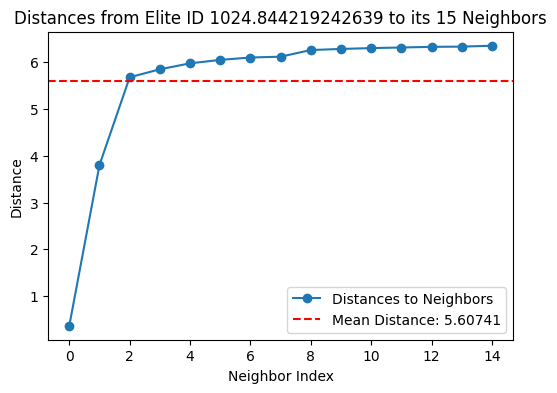

Elite ID: 638.7066598660713
Distances: [3.75736819 3.80136864 5.35232625 5.51107603 5.53081925 5.67795021
 5.78278661 5.94939379 5.99302853 6.10376545 6.16450201 6.20944323
 6.2128819  6.23048156 6.26993508]
Mean distance to neighbors: 5.63648
---


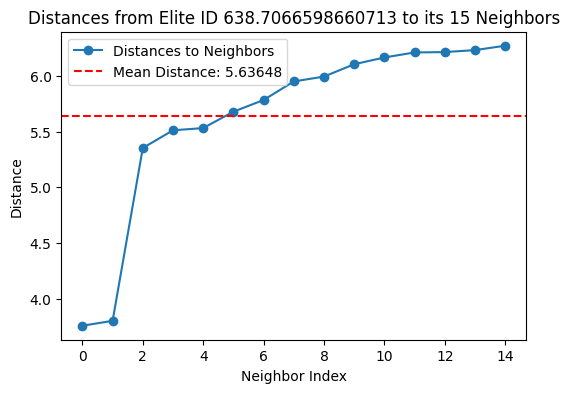

In [ ]:
# Same as above, but WITHOUT excluding the selected elites from the neighbor pool.
# We fit on the full elite set, so a selected elite can be a neighbor of another.
# We query n_neighbors+1 and drop the first match (the elite itself at distance 0).
from sklearn.neighbors import NearestNeighbors

all_embeddings = [elite["embedding"] for elite in elites]

n_neighbors = 15
knn_all = NearestNeighbors(n_neighbors=n_neighbors + 1)
knn_all.fit(all_embeddings)

for i, elite in enumerate(selected_elites):
    elite_id = elite["id"]
    elite_embedding = elite["embedding"]
    distances, indices = knn_all.kneighbors([elite_embedding])
    # drop the first neighbor (the query elite itself, distance ~0)
    distances = distances[:, 1:]
    indices = indices[:, 1:]
    mean_distance = np.mean(distances)
    print(f"Elite ID: {elite_id}")
    print(f"Distances: {distances[0]}")
    print(f"Mean distance to neighbors: {mean_distance:.5f}")
    print("---")
    # plot distances and mean distance
    plt.figure(figsize=(6, 4))
    plt.plot(distances[0], marker='o', label='Distances to Neighbors')
    plt.axhline(mean_distance, color='red', linestyle='--', label=f'Mean Distance: {mean_distance:.5f}')
    plt.title(f"Distances from Elite ID {elite_id} to its {n_neighbors} Neighbors")
    plt.xlabel("Neighbor Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()